# Iceland Under Pressure: Explainer Notebook

**Course:** 02806 Social Data Analysis and Visualization, Spring 2026  
**Authors:** Ylfa Margrét Ólafsdóttir and Tanja Kristín Árnadóttir  
**Website:** (https://github.com/Tanjaa21/s252892.github.io)

This notebook is the technical explainer behind our final data story website. The website is designed for a non-technical audience, while this notebook documents the data sources, cleaning, analysis, design choices, and visualization code behind the story.

Our main story is that Iceland's housing pressure is not just a feeling. It can be seen in the gap between housing prices and income, declining ownership, poor housing conditions, a post-crash slowdown in housing construction, and the pressure added by short-term rentals in Reykjavík.


## 1. Motivation

### What is the dataset?

The project combines public datasets about Icelandic housing, population, income, and housing-market pressure. The final analysis is built as an annual panel where each row represents one year and each column represents one social or housing-related indicator.

To keep the explainer notebook aligned with the final website, we only keep the datasets that are actually used in the visualizations or directly support them.

The main datasets used are:

| Variable | Source / file used in notebook | Why it matters |
|---|---|---|
| Mean income by age group | `TEK01001` | Shows whether incomes kept up with housing prices |
| Population | `MAN10001`, `MAN08000` | Shows long-term and annual population growth |
| Owner-occupier rate | `LIF03210` | Shows changes in access to ownership |
| People in poor housing | `LIF03340` | Shows who is affected by housing stress |
| Residential price index | `VIS01106` | Measures housing price development |
| Consumer price index | `VIS01005` | Used to contextualize real price changes |
| Loan burden | HMS monthly report sheet `LM.1` | Adds affordability context |
| Dwellings begun | `IDN03001` | Shows whether new housing supply increased |
| Population vs dwelling growth | HMS sheet `BM.2` | Shows whether homes kept up with people |
| Airbnb listings | Airbnb CSV | Shows how short-term rentals occupy space in Reykjavík |

### Why did we choose these datasets?

We chose these datasets because we wanted to explain a change we have felt personally as Icelanders: Iceland feels more pressured, less affordable, and harder to enter for people trying to build a life there. Instead of only describing that feeling, we wanted to test it through data.

The datasets let us connect several parts of the story: income, prices, ownership, housing stress, construction, population growth, and Airbnb. No single dataset explains the whole problem, but together they show how pressure builds from several directions.

### Goal for the end user's experience

The website is written for a non-technical reader. We wanted the reader to understand the story without needing to understand code, statistics, or data cleaning.

The intended experience is:

1. Start with a relatable feeling: Iceland feels under pressure.
2. Show that this feeling is visible in the data.
3. Move from broad national trends to more concrete housing pressure.
4. Let the reader explore selected visualizations without losing the main story.
5. End with a clear takeaway: pressure in Iceland is not caused by one factor, but by several trends moving together.


## 2. Setup and paths

This notebook assumes the raw data files are stored in a folder called `data/` and that exported files are written to `outputs/`. If the files are stored somewhere else, only this setup cell needs to be changed.


In [101]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from functools import reduce
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Please change this
DATA_DIR = Path('/Users/tanjakristin/Desktop/Python/s252892.github.io/notebook/Data/')
OUT_DIR = Path('/Users/tanjakristin/Desktop/Python/s252892.github.io/notebook/Data/')
OUT_DIR.mkdir(exist_ok=True)

# Save static charts (PNG) to the images folder, interactive charts (HTML) to visualizations
IMAGES_DIR = Path('/Users/tanjakristin/Desktop/Python/s252892.github.io/images/')
VIZ_DIR = Path('/Users/tanjakristin/Desktop/Python/s252892.github.io/visualizations/')
IMAGES_DIR.mkdir(exist_ok=True)
VIZ_DIR.mkdir(exist_ok=True)

# Raw input files
PATH_TEK    = DATA_DIR / 'TEK01001_20260429-205548.xlsx'
PATH_MAN10  = DATA_DIR / 'MAN10001_20260429-185904.xlsx'
PATH_LIF210 = DATA_DIR / 'LIF03210_20260429-190103.xlsx'
PATH_LIF340 = DATA_DIR / 'LIF03340_20260429-191006.xlsx'
PATH_VIS    = DATA_DIR / 'VIS01106_20260429-195620.xlsx'
PATH_CPI    = DATA_DIR / 'VIS01005_20260429-195830.xlsx'
PATH_HMS    = DATA_DIR / 'aMmcEWGNHVfTPSjX_Gogn_manadarskyrsla_agust25HMS-1-.xlsx'
PATH_IDN    = DATA_DIR / 'IDN03001_20260429-205330.xlsx'
PATH_AIRBNB = DATA_DIR / 'part-00442-e685bf03-a693-439c-b3bb-b8b063ff0db5.c000.csv'
PATH_POP_LONG = DATA_DIR / 'MAN08000_20260429-212856.xlsx'

# Exported analysis files
PATH_PANEL = OUT_DIR / 'iceland_panel.csv'
PATH_INCOME_AGE = OUT_DIR / 'iceland_income_by_age.csv'
PATH_AIRBNB_TRIMMED = OUT_DIR / 'airbnb_iceland.csv'


## 3. Basic stats and preprocessing

The data cleaning and merging is done in a separate notebook (`data_merging.ipynb`) — that notebook produces three CSV files (`iceland_panel.csv`, `iceland_income_by_age.csv`, `airbnb_iceland.csv`) which are loaded in the visualization section below. The merged dataset is also committed to the GitHub repository so the merge result can be inspected without running any code.

The quick checks on the panel (shape, head/tail, missing values, summary statistics) are run after the data is loaded.


In [102]:
import plotly.graph_objects as go

# Colours used across the story
C1  = '#B01020'
C2  = '#ECA090'
C3  = '#F5D5CC'
BG  = '#FDF6F3'
INK = '#1C0A08'
MUT = '#8C5A52'

matplotlib.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': True,
    'axes.edgecolor': C3, 'grid.color': C3, 'grid.linewidth': 0.5,
    'xtick.color': MUT, 'ytick.color': MUT,
})

# Load cleaned data created above
panel = pd.read_csv(PATH_PANEL)
income_age = pd.read_csv(PATH_INCOME_AGE)
airbnb = pd.read_csv(PATH_AIRBNB_TRIMMED)

# Load long-run population data used for the construction/population chart
raw_pop = pd.read_excel(PATH_POP_LONG, header=None)
years_pop = [int(y) for y in raw_pop.iloc[2, 2:].tolist() if pd.notna(y)]
total_pop = raw_pop.iloc[3, 2:2+len(years_pop)].tolist()
pop_df = pd.DataFrame({
    'year': years_pop,
    'population': [pd.to_numeric(v, errors='coerce') for v in total_pop]
}).dropna()
pop_df['pop_growth'] = pop_df['population'].pct_change() * 100
pop_df = pop_df.dropna().reset_index(drop=True)

print('All visualization data loaded successfully.')
print(f'panel: {panel.shape[0]} rows, years {int(panel.year.min())}–{int(panel.year.max())}')
print(f'income_age: {income_age.shape[0]} rows, buckets: {list(income_age.bucket.unique())}')
print(f'airbnb: {airbnb.shape[0]} listings')
print(f'pop_df: {pop_df.shape[0]} rows, years {int(pop_df.year.min())}–{int(pop_df.year.max())}')


All visualization data loaded successfully.
panel: 58 rows, years 1970–2027
income_age: 140 rows, buckets: ['16–29', '30–44', '45–59', '60+']
airbnb: 289 listings
pop_df: 184 rows, years 1842–2025


### Quick checks on the final panel

After the merge, we do a few simple checks: the number of rows and columns, missing values, and summary statistics for the variables used in the visualizations. These checks are here to make the workflow transparent without making the merge section too large.


In [103]:
print(f'Panel shape: {panel.shape[0]} rows × {panel.shape[1]} columns')
print(f'Year range: {int(panel.year.min())}–{int(panel.year.max())}')

display(panel.head())
display(panel.tail())


Panel shape: 58 rows × 19 columns
Year range: 1970–2027


,year,mean_income_kisk_total,population,owner_occupier_pct,n_poor_housing,residential_price_index,cpi,avg_loan_payment_per_10m_isk,dwellings_begun,pop_growth_rate,dwelling_growth_rate,income_idx,price_idx,real_price_index,monthly_income_isk,loan_burden_pct_income,poor_housing_pct,gap,cumulative_gap
0,1970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1469.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1833.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1963.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3377.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2640.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,year,mean_income_kisk_total,population,owner_occupier_pct,n_poor_housing,residential_price_index,cpi,avg_loan_payment_per_10m_isk,dwellings_begun,pop_growth_rate,dwelling_growth_rate,income_idx,price_idx,real_price_index,monthly_income_isk,loan_burden_pct_income,poor_housing_pct,gap,cumulative_gap
53,2023,9347.0,383760.0,NaN,NaN,702.216667,592.8,51678.821514,NaN,0.032519,0.022518,431.333641,670.629994,235.849086,778916.666667,6.634705,NaN,0.010001,-0.003579
54,2024,9973.0,389450.0,NaN,NaN,758.783333,627.5,55664.118680,NaN,0.027711,0.023648,460.221504,724.652214,240.754999,831083.333333,6.697778,NaN,0.004063,0.000484
55,2025,NaN,394530.0,NaN,NaN,797.833333,653.1,55782.339125,NaN,0.019325,0.021116,NaN,761.945691,243.222503,NaN,NaN,NaN,-0.001791,-0.001307
56,2026,NaN,NaN,NaN,NaN,813.100000,NaN,NaN,NaN,0.028989,0.016667,NaN,776.525642,NaN,NaN,NaN,NaN,0.012322,0.011015
57,2027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.024233,0.018215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [104]:
# Missing values in the final annual panel
missing = panel.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])


poor_housing_pct                49
owner_occupier_pct              45
n_poor_housing                  43
population                      42
cumulative_gap                  37
gap                             37
loan_burden_pct_income          37
dwelling_growth_rate            36
pop_growth_rate                 36
avg_loan_payment_per_10m_isk    36
real_price_index                32
price_idx                       31
residential_price_index         31
mean_income_kisk_total          23
income_idx                      23
monthly_income_isk              23
cpi                             20
dwellings_begun                  6
dtype: int64

In [105]:
# Descriptive statistics for selected story variables
story_cols = [
    'year', 'mean_income_kisk_total', 'income_idx', 'price_idx',
    'owner_occupier_pct', 'n_poor_housing', 'population',
    'dwellings_begun', 'pop_growth_rate', 'dwelling_growth_rate'
]
existing_cols = [c for c in story_cols if c in panel.columns]
display(panel[existing_cols].describe())


,year,mean_income_kisk_total,income_idx,price_idx,owner_occupier_pct,n_poor_housing,population,dwellings_begun,pop_growth_rate,dwelling_growth_rate
count,58.000000,35.000000,35.000000,27.000000,13.000000,15.000000,16.000000,52.000000,22.000000,22.000000
mean,1998.500000,4141.828571,191.131914,339.419573,81.784615,53553.933333,347172.500000,1916.769231,0.017996,0.017222
std,16.886879,2529.533699,116.729751,211.466324,4.021576,9585.682184,28333.666076,1018.357648,0.013391,0.008864
min,1970.000000,1116.000000,51.499769,100.000000,77.300000,32751.000000,311890.000000,142.000000,-0.021379,0.005545
25%,1984.250000,1868.000000,86.202123,206.797345,77.900000,48595.000000,322287.500000,1332.250000,0.012452,0.009352
50%,1998.500000,4018.000000,185.417628,246.768854,81.300000,54646.000000,345890.000000,1752.000000,0.019798,0.017441
75%,2012.750000,5719.500000,263.936317,443.216184,85.800000,60204.000000,367545.000000,2371.500000,0.028333,0.022584
max,2027.000000,9973.000000,460.221504,776.525642,86.900000,66667.000000,394530.000000,4446.000000,0.034014,0.042287


## 4. Data analysis

The analysis asks how Icelandic housing pressure developed over time. The central comparison is between income growth and housing price growth. We then add supporting indicators: ownership, poor housing conditions, construction, population growth, and Airbnb concentration in Reykjavík.

The project does not use machine learning. This was a deliberate choice. The story is mainly explanatory rather than predictive, and the strongest contribution comes from combining multiple public indicators into a clear visual narrative.

The main analytical findings are:

1. Housing prices increased much faster than income after the 2000 baseline.
2. Ownership became less accessible over the period where housing stress increased.
3. The 2008 financial crisis is visible as an important break in the housing story.
4. Construction did not consistently keep pace with population pressure.
5. Airbnb adds another layer to the Reykjavík housing story by showing homes used as short-term rental assets.


## 5. Visualization code

This section contains the visualization code used for the website. Static charts are exported as PNG files, while interactive visualizations are exported as standalone HTML files that can be embedded in the website.

The visual style is intentionally consistent across charts: warm background, dark red emphasis, and simple labels. The website is meant to feel like an editorial data story rather than a technical dashboard.


In [106]:
import plotly.graph_objects as go

# Colours used across the story
C1  = '#B01020'
C2  = '#ECA090'
C3  = '#F5D5CC'
BG  = '#FDF6F3'
INK = '#1C0A08'
MUT = '#8C5A52'

matplotlib.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': True,
    'axes.edgecolor': C3, 'grid.color': C3, 'grid.linewidth': 0.5,
    'xtick.color': MUT, 'ytick.color': MUT,
})


### Visualization 1 — The Affordability Squeeze

This is the opening evidence chart on the website. It compares the indexed growth of housing prices and income using 2000 as the baseline. This is the right visual for the story because it makes the affordability gap visible immediately: even if income rises, the key question is whether it rises fast enough to keep up with housing prices.


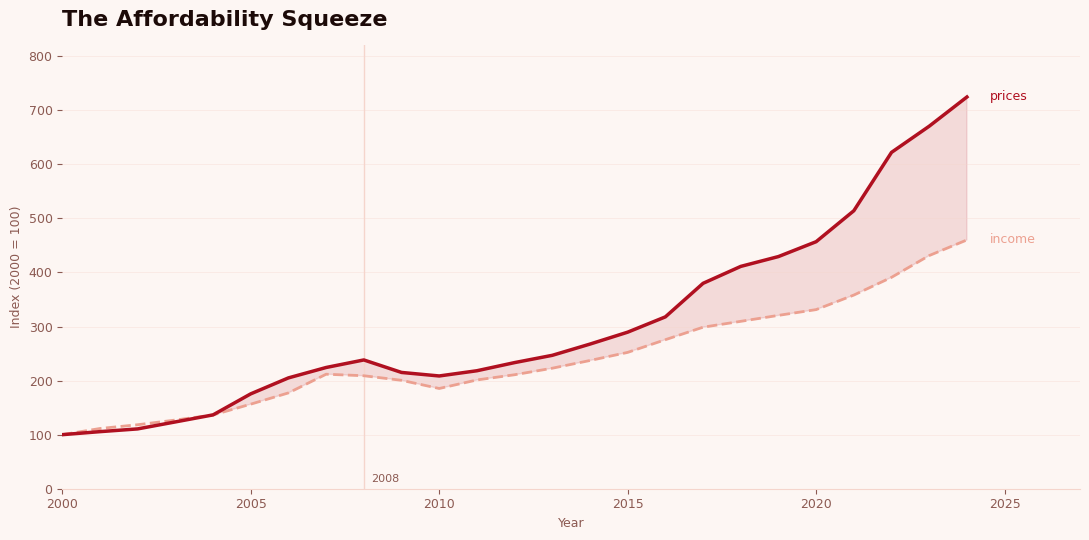

Saved chart1_squeeze.png


In [107]:
ch1 = panel[panel.year.between(2000, 2024)].dropna(subset=['income_idx', 'price_idx']).copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(BG)
ax.fill_between(ch1.year, ch1.income_idx, ch1.price_idx,
                where=ch1.price_idx >= ch1.income_idx, color=C1, alpha=0.12)
ax.plot(ch1.year, ch1.price_idx, color=C1, lw=2.5, zorder=4)
ax.plot(ch1.year, ch1.income_idx, color=C2, lw=2, linestyle='--', zorder=3)
ax.text(2024.6, ch1.price_idx.iloc[-1], 'prices', fontsize=9, color=C1, va='center')
ax.text(2024.6, ch1.income_idx.iloc[-1], 'income', fontsize=9, color=C2, va='center')
ax.axvline(2008, color=C3, lw=1)
ax.text(2008.2, 12, '2008', fontsize=8, color=MUT)
ax.set_title('The Affordability Squeeze', fontsize=16, fontweight='bold', color=INK, pad=14, loc='left')
ax.set_ylabel('Index (2000 = 100)', fontsize=9, color=MUT)
ax.set_xlabel('Year', fontsize=9, color=MUT)
ax.set_xlim(2000, 2027)
ax.set_ylim(0, 820)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.grid(axis='y', alpha=0.5)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart1_squeeze.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved chart1_squeeze.png')

### Visualization 2 — Falling Out of Ownership

This chart connects access to ownership with housing stress. The mirrored layout lets the reader compare two related indicators in the same time period: the share of owner-occupiers and the number of people living in poor housing conditions.


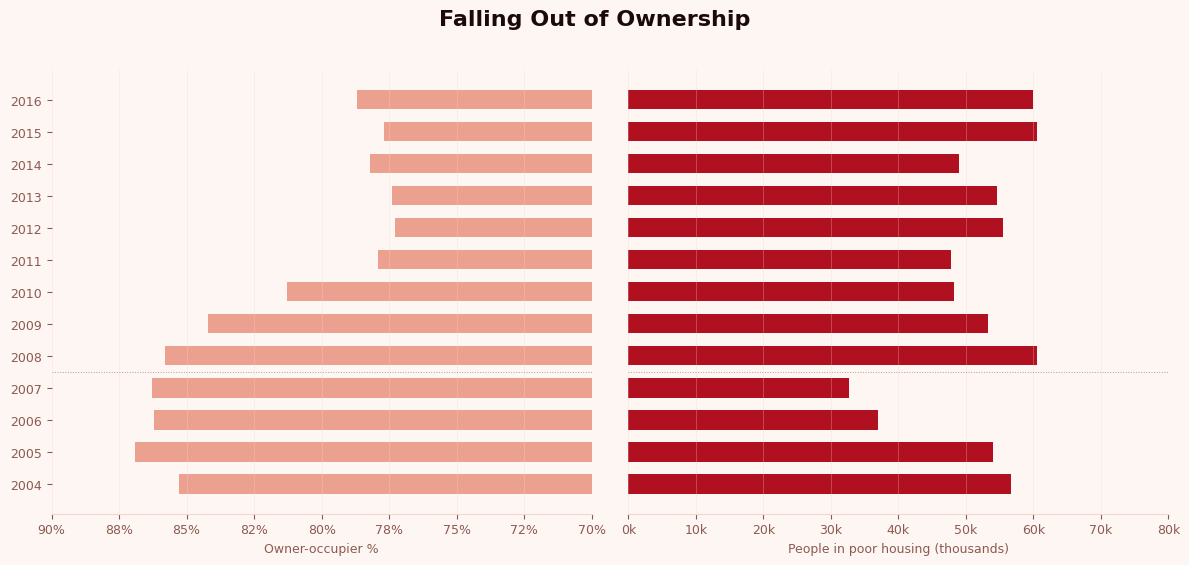

Saved chart2_ownership.png


In [108]:
ch2 = panel[panel.year.between(2004, 2018)].dropna(subset=['owner_occupier_pct', 'n_poor_housing']).copy()
years2 = ch2.year.values.astype(int)
y = np.arange(len(years2))

fig, (al, ar) = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
fig.patch.set_facecolor(BG)
fig.subplots_adjust(wspace=0)
al.barh(y, ch2.owner_occupier_pct, color=C2, height=0.6)
al.set_xlim(90, 70)
al.set_yticks(y)
al.set_yticklabels(years2, fontsize=9, color=MUT)
al.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
al.grid(axis='x', alpha=0.4)
al.tick_params(labelsize=9)
al.spines['left'].set_visible(False)
al.set_xlabel('Owner-occupier %', fontsize=9, color=MUT)
ar.barh(y, ch2.n_poor_housing / 1000, color=C1, height=0.6)
ar.set_xlim(0, 80)
ar.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}k'))
ar.grid(axis='x', alpha=0.4)
ar.tick_params(labelsize=9, left=False)
ar.set_xlabel('People in poor housing (thousands)', fontsize=9, color=MUT)
ci = list(years2).index(2008)
for ax in [al, ar]:
    ax.axhline(ci - 0.5, color=MUT, lw=0.7, linestyle=':', alpha=0.6)
fig.suptitle('Falling Out of Ownership', fontsize=16, fontweight='bold', color=INK, y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart2_ownership.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved chart2_ownership.png')

### Visualization 3 — Housing Stress

This bar chart focuses directly on people living in poor housing conditions. It supports the human side of the story: housing pressure is not only about prices, but about people being pushed into worse living situations.


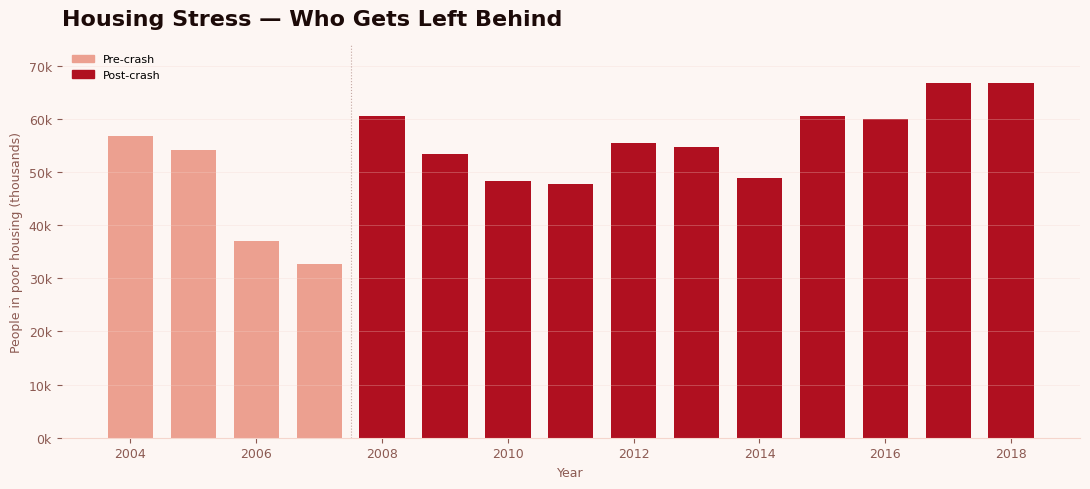

Saved chart4_poor_housing.png


In [109]:
ch4 = panel[panel.year.between(2004, 2018)].dropna(subset=['n_poor_housing']).copy()

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)
bar_colors = [C2 if yr <= 2007 else C1 for yr in ch4.year]
ax.bar(ch4.year, ch4.n_poor_housing / 1000, color=bar_colors, width=0.72)
ax.axvline(2007.5, color=MUT, lw=0.8, linestyle=':', alpha=0.5)
ax.set_title('Housing Stress — Who Gets Left Behind', fontsize=16, fontweight='bold', color=INK, pad=14, loc='left')
ax.set_ylabel('People in poor housing (thousands)', fontsize=9, color=MUT)
ax.set_xlabel('Year', fontsize=9, color=MUT)
ax.set_ylim(0, 74)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.grid(axis='y', alpha=0.4)
ax.tick_params(labelsize=9)
ax.legend(handles=[
    mpatches.Patch(color=C2, label='Pre-crash'),
    mpatches.Patch(color=C1, label='Post-crash'),
], frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart3_poor_housing.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved chart4_poor_housing.png')

### Visualization 4 — The Missing Homes

This chart combines dwellings begun with population growth. It is useful because it connects housing supply to demographic pressure. The 2008 marker helps explain why the story changes after the financial crisis.


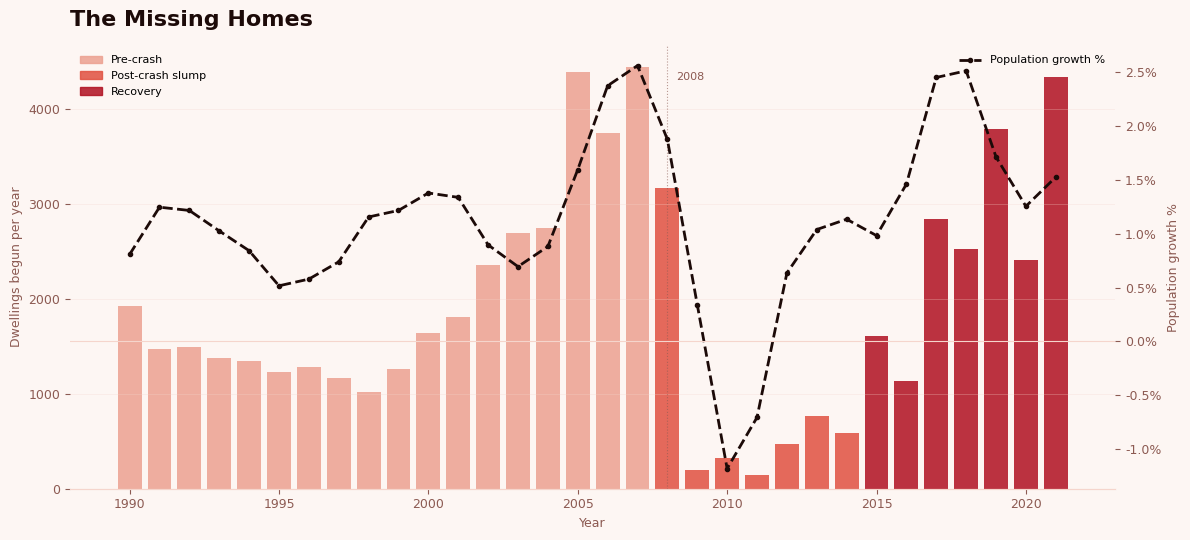

Saved chart5_missing_homes.png


In [110]:
ch5     = panel[panel.year.between(1990, 2021)].dropna(subset=['dwellings_begun']).copy()
ch5_pop = pop_df[pop_df.year.between(1990, 2021)].copy()

fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor(BG)

bar_colors = [C2 if yr <= 2007 else '#E05040' if yr <= 2014 else C1
              for yr in ch5.year]
ax.bar(ch5.year, ch5.dwellings_begun, color=bar_colors, width=0.8, alpha=0.85)

ax2 = ax.twinx()
ax2.plot(ch5_pop.year, ch5_pop.pop_growth,
         color=INK, lw=2, linestyle='--', marker='o', markersize=3,
         label='Population growth %')
ax2.axhline(0, color=C3, lw=0.8)
ax2.set_ylabel('Population growth %', fontsize=9, color=MUT)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.tick_params(labelsize=9, colors=MUT)
ax2.spines['right'].set_color(C3)
ax2.spines['top'].set_visible(False)
ax2.legend(loc='upper right', frameon=False, fontsize=8)

ax.axvline(2008, color=MUT, lw=0.8, linestyle=':', alpha=0.6)
ax.text(2008.3, 4300, '2008', fontsize=8, color=MUT)
ax.set_title('The Missing Homes', fontsize=16, fontweight='bold', color=INK, pad=14, loc='left')
ax.set_ylabel('Dwellings begun per year', fontsize=9, color=MUT)
ax.set_xlabel('Year', fontsize=9, color=MUT)
ax.grid(axis='y', alpha=0.4)
ax.tick_params(labelsize=9)
ax.legend(handles=[
    mpatches.Patch(color=C2,       alpha=0.85, label='Pre-crash'),
    mpatches.Patch(color='#E05040',alpha=0.85, label='Post-crash slump'),
    mpatches.Patch(color=C1,       alpha=0.85, label='Recovery'),
], frameon=False, fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'chart4_missing_homes.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved chart5_missing_homes.png')

### Visualization 5 — Income by age vs house prices

This interactive chart lets the reader compare house prices with income growth for different age groups. It fits the martini glass structure because the reader first receives the guided story, then gets a controlled way to explore which age groups are most affected.


In [111]:
buckets = ['16–29', '30–44', '45–59', '60+']
bucket_colors = {
    '16–29': '#ECA090',
    '30–44': '#E05040',
    '45–59': '#B01020',
    '60+':   '#7A0A14'
}
price_sub = panel[panel.year.between(1990, 2024)].dropna(subset=['price_idx']).copy()

fig6 = go.Figure()

for i, bucket in enumerate(buckets):
    sub = income_age[income_age['bucket'] == bucket].sort_values('year').copy()
    base = sub.loc[sub.year == 2000, 'mean_income_kisk'].values[0]
    sub['income_idx'] = sub['mean_income_kisk'] / base * 100
    fig6.add_trace(go.Scatter(
        x=sub['year'], y=sub['income_idx'].round(1),
        mode='lines', name=f'Income {bucket}',
        line=dict(color=bucket_colors[bucket], width=2.5),
        visible=(i == 0)
    ))

fig6.add_trace(go.Scatter(
    x=price_sub['year'], y=price_sub['price_idx'].round(1),
    mode='lines', name='House prices',
    line=dict(color=C1, width=2.5),
    visible=True
))

n_buckets = len(buckets)
buttons = []
for i, bucket in enumerate(buckets):
    visibility = [j == i for j in range(n_buckets)] + [True]
    buttons.append(dict(label=f'Age {bucket}', method='update',
                        args=[{'visible': visibility}]))

fig6.update_layout(
    title='House prices vs income — select age group',
    plot_bgcolor=BG, paper_bgcolor=BG,
    xaxis=dict(title='Year', showgrid=False, tickfont=dict(color=MUT)),
    yaxis=dict(title='Index (2000 = 100)', range=[0, 820],
               gridcolor=C3, tickfont=dict(color=MUT)),
    legend=dict(font=dict(size=11), bgcolor='rgba(0,0,0,0)', x=0.02, y=0.98),
    margin=dict(t=80, b=60, l=60, r=40),
    updatemenus=[dict(
        type='buttons', direction='right',
        x=0.0, y=1.09
    , xanchor='left', showactive=True,
        buttons=buttons, bgcolor=C3, bordercolor=C2,
        font=dict(color=INK, size=11)
    )]
)

fig6.write_html(VIZ_DIR / 'chart5_income_by_age.html', include_plotlyjs='cdn')
fig6.show()
print('Saved chart6_income_by_age.html')

Saved chart6_income_by_age.html


### Visualization 6 — Airbnb's grip on Reykjavík

This interactive map adds spatial context. It shows short-term rental listings in Reykjavík and helps the reader see housing pressure as something physical and local, not just abstract national statistics.


In [112]:
entire  = airbnb[airbnb.room_type == 'entire_home'].copy()
private = airbnb[airbnb.room_type == 'private_room'].copy()

def rev_size(s):
    s = pd.to_numeric(s, errors='coerce').fillna(0)
    mn, mx = s.min(), s.max()
    if mx == mn:
        return [10] * len(s)
    return (6 + 14 * (s - mn) / (mx - mn)).round(1).tolist()

fig7 = go.Figure()
for df_sub, color, label in [(entire, C1, 'Entire home'), (private, C2, 'Private room')]:
    fig7.add_trace(go.Scattermapbox(
        lat=df_sub.latitude, lon=df_sub.longitude,
        mode='markers',
        marker=dict(size=rev_size(df_sub.ttm_revenue_native), color=color, opacity=0.75),
        text=df_sub.apply(lambda r:
            f"{label}<br>"
            f"Revenue: {int(r.ttm_revenue_native/1000) if pd.notna(r.ttm_revenue_native) else '?'}k ISK/yr<br>"
            f"Occupancy: {int(r.ttm_occupancy*100) if pd.notna(r.ttm_occupancy) else '?'}%",
            axis=1),
        hoverinfo='text', name=label
    ))

fig7.update_layout(
    mapbox=dict(style='carto-positron', center=dict(lat=64.135, lon=-21.895), zoom=12),
    title=dict(text="Airbnb's Grip on Reykjavík", font=dict(size=18, color=INK)),
    legend=dict(font=dict(size=11), bgcolor='rgba(253,246,243,0.9)',
                bordercolor=C3, borderwidth=1),
    margin=dict(t=60, b=0, l=0, r=0),
    height=520, paper_bgcolor=BG
)

fig7.write_html(VIZ_DIR / 'chart6_airbnb_map.html', include_plotlyjs='cdn')
fig7.show()
print('Saved chart7_airbnb_map.html')

Saved chart7_airbnb_map.html


## 6. Genre and narrative design

### Genre: Which genre of data story did we use?

We used the **Martini Glass** genre from Segel and Heer (2010).

The website begins with a guided, author-driven story. The reader is taken through the argument in a fixed order:

**affordability gap → missing homes → ownership → housing stress → age groups → Airbnb → conclusion**

This fits the martini glass structure because the first part is linear and controlled. The reader is guided through the main explanation before the story opens up into more exploration through the interactive age-income chart and Airbnb map.

We chose this genre because our topic needs context. Housing affordability is affected by several connected factors, so a fully open dashboard could make the message unclear. The martini glass structure helps us present the argument first, then give the reader space to explore selected details.


### Visual Narrative tools used

### 1. Visual structuring

We used **consistent visual platform** as our main visual structuring tool. The website uses the same colors, typography, chapter layout, captions, and spacing throughout the story.

We used this because the project contains many different indicators, such as prices, income, construction, ownership, poor housing, and Airbnb. A consistent design makes the website feel like one connected story instead of separate charts.

### 2. Highlighting

We used **color emphasis and captions** as highlighting tools. Important patterns are highlighted with the same red and pink color palette, and each visualization includes a caption that begins with the main takeaway.

We used this because the reader should not have to guess what matters in each chart. The highlighting points attention toward the key message, such as the widening gap between prices and incomes or the concentration of Airbnb listings.

### 3. Transition guidance

We used **chapter structure and section ordering** as transition guidance. Each section leads naturally into the next: the price-income gap introduces the affordability problem, construction explains supply pressure, and ownership and poor housing show the social consequences.

We used this because the story has several connected causes and effects. Transition guidance helps the reader understand why each chart appears and how it adds to the overall argument.


### Narrative Structure tools used

### 1. Ordering

We used **linear ordering**. The website follows a fixed scroll-based sequence from the broad affordability problem to more specific forms of pressure.

We used this because the argument needs to build step by step. Starting with Airbnb or age groups would be less clear without first explaining the overall affordability squeeze.

### 2. Interactivity

We used **filtering and details-on-demand**. The age-income chart lets users choose age groups, and the Airbnb map allows users to hover over listings to see more details.

We used this because interaction adds value in these cases. It lets readers explore differences between groups and locations without overwhelming the main story.

### 3. Messaging

We used **captions, introductory text, and summary/synthesis**. Each section has a short explanation before the visualization and a caption after it. The conclusion brings the different patterns together.

We used this because our goal was to make the project understandable for a general audience, not only for people who are comfortable reading data visualizations.

## 8. Discussion
### What went well?

The visualizations work well together as one story. Instead of relying on one chart, the project builds evidence across prices, incomes, construction, ownership, poor housing, population growth, and Airbnb.

The topic also worked well because it is personally relevant to us as Icelanders, while still being supported by public data. The martini glass structure helped guide the reader first and then allowed for more exploration in the interactive charts.

### What is still missing?

The main limitation is that some data is too aggregated. National averages hide differences between Reykjavík, smaller towns, rural areas, renters, homeowners, and different age groups.

More rental data would also make the project stronger. Rental prices, rent-to-income ratios, and rental availability would better show how young people experience the housing squeeze before buying a home.

The Airbnb data is useful, but it is only a snapshot. It shows where short-term rentals are located, but not exactly how much they affect rents or house prices.

### What could be improved, and why?

The project could be improved with more local-level housing data, especially for Reykjavík and different municipalities. This would help show where the pressure is strongest.

It could also include more rental market data and a comparison with other Nordic countries. This would make it easier to understand whether Iceland’s affordability problem is unique or part of a wider pattern.

## 9. Contributions

The work was divided by task area rather than described as equal contribution.

**Ylfa Margrét Ólafsdóttir** took the lead on the data cleaning workflow, merging datasets into the annual panel, producing the visualization code, working with GitHub Pages, and translating the analysis into the website structure.

**Tanja Kristín Árnadóttir** took the lead on framing the topic, writing the explanatory website text, connecting the findings to the broader Icelandic context, and evaluating whether the story was understandable for a non-technical audience.

Both group members contributed to the story angle, visualization selection, interpretation of findings, and final review of the website and notebook.


## 10. References

Segel, E., & Heer, J. (2010). *Narrative Visualization: Telling Stories with Data*. IEEE Transactions on Visualization and Computer Graphics, 16(6), 1139–1148.

Statistics Iceland. (n.d.). *Income, population, housing conditions, owner-occupier status, residential price index, consumer price index, and dwellings data*. Retrieved from Statistics Iceland database.

Housing and Construction Authority of Iceland / HMS. (n.d.). *Monthly housing market report data*, including loan burden and population versus dwelling growth indicators.

Airbnb listing dataset. (n.d.). Reykjavík / Iceland short-term rental listing data used for the interactive map. Add exact source URL and access date here.

Image references for the website should be listed here with source, creator if available, URL, and access date.
